<IPython.core.display.Javascript object>


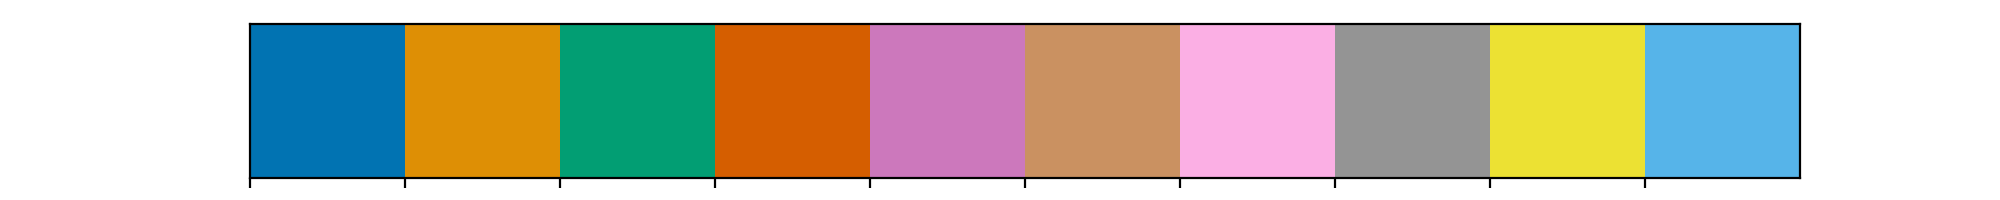

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from astropy.coordinates import Angle
import astropy.units as u
import pickle

from matplotlib.colors import Normalize
from astropy.coordinates import SkyCoord

from scipy.interpolate import interp1d

pal = sns.color_palette("colorblind")

%matplotlib notebook

sns.palplot(pal)

In [2]:
key = "crn"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (crn_track, crn_ha_fit_results, crn_hi_fit_results, 
                 crn_Ha_H_neg, crn_Ha_H_pos, crn_HI_H_neg, crn_HI_H_pos) = pickle.load(f)
    
key = "crf"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (crf_track, crf_ha_fit_results, crf_hi_fit_results, 
                 crf_Ha_H_neg, crf_Ha_H_pos, crf_HI_H_neg, crf_HI_H_pos) = pickle.load(f)
    
key = "per"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (per_track, per_ha_fit_results, per_hi_fit_results, 
                 per_Ha_H_neg, per_Ha_H_pos, per_HI_H_neg, per_HI_H_pos) = pickle.load(f)
    
key = "sgn"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (sgn_track, sgn_ha_fit_results, sgn_hi_fit_results, 
                 sgn_Ha_H_neg, sgn_Ha_H_pos, sgn_HI_H_neg, sgn_HI_H_pos) = pickle.load(f)
    
key = "sgf"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (sgf_track, sgf_ha_fit_results, sgf_hi_fit_results, 
                 sgf_Ha_H_neg, sgf_Ha_H_pos, sgf_HI_H_neg, sgf_HI_H_pos) = pickle.load(f)
    
key = "scn"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (scn_track, scn_ha_fit_results, scn_hi_fit_results, 
                 scn_Ha_H_neg, scn_Ha_H_pos, scn_HI_H_neg, scn_HI_H_pos) = pickle.load(f)
    

key = "ctn"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (ctn_track, ctn_ha_fit_results, ctn_hi_fit_results, 
                 ctn_Ha_H_neg, ctn_Ha_H_pos, ctn_HI_H_neg, ctn_HI_H_pos) = pickle.load(f)    


In [3]:
crn_vel_interpolator = interp1d(crn_track[:,0], crn_track[:,2])
crn_vel_smooth_ha = crn_vel_interpolator(crn_ha_fit_results["smoothed_longitude"])
crn_vel_smooth_hi = crn_vel_interpolator(crn_hi_fit_results["smoothed_longitude"])

crf_vel_interpolator = interp1d(crf_track[:,0], crf_track[:,2])
crf_vel_smooth_ha = crf_vel_interpolator(crf_ha_fit_results["smoothed_longitude"])
crf_vel_smooth_hi = crf_vel_interpolator(crf_hi_fit_results["smoothed_longitude"])

ctn_vel_interpolator = interp1d(ctn_track[:,0], ctn_track[:,2])
ctn_vel_smooth_ha = ctn_vel_interpolator(ctn_ha_fit_results["smoothed_longitude"])
ctn_vel_smooth_hi = ctn_vel_interpolator(ctn_hi_fit_results["smoothed_longitude"])

per_vel_interpolator = interp1d(per_track[:,0], per_track[:,2], fill_value=np.nan, bounds_error=False)
per_vel_smooth_ha = per_vel_interpolator(per_ha_fit_results["smoothed_longitude"])
per_vel_smooth_hi = per_vel_interpolator(per_hi_fit_results["smoothed_longitude"])

sgn_vel_interpolator = interp1d(sgn_track[:,0], sgn_track[:,2])
sgn_vel_smooth_ha = sgn_vel_interpolator(sgn_ha_fit_results["smoothed_longitude"])
sgn_vel_smooth_hi = sgn_vel_interpolator(sgn_hi_fit_results["smoothed_longitude"])

sgf_vel_interpolator = interp1d(sgf_track[:,0], sgf_track[:,2])
sgf_vel_smooth_ha = sgf_vel_interpolator(sgf_ha_fit_results["smoothed_longitude"])
sgf_vel_smooth_hi = sgf_vel_interpolator(sgf_hi_fit_results["smoothed_longitude"])

scn_vel_interpolator = interp1d(scn_track[:,0], scn_track[:,2])
scn_vel_smooth_ha = scn_vel_interpolator(scn_ha_fit_results["smoothed_longitude"])
scn_vel_smooth_hi = scn_vel_interpolator(scn_hi_fit_results["smoothed_longitude"])

In [4]:
from matplotlib.collections import LineCollection
def colored_line(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

<IPython.core.display.Javascript object>


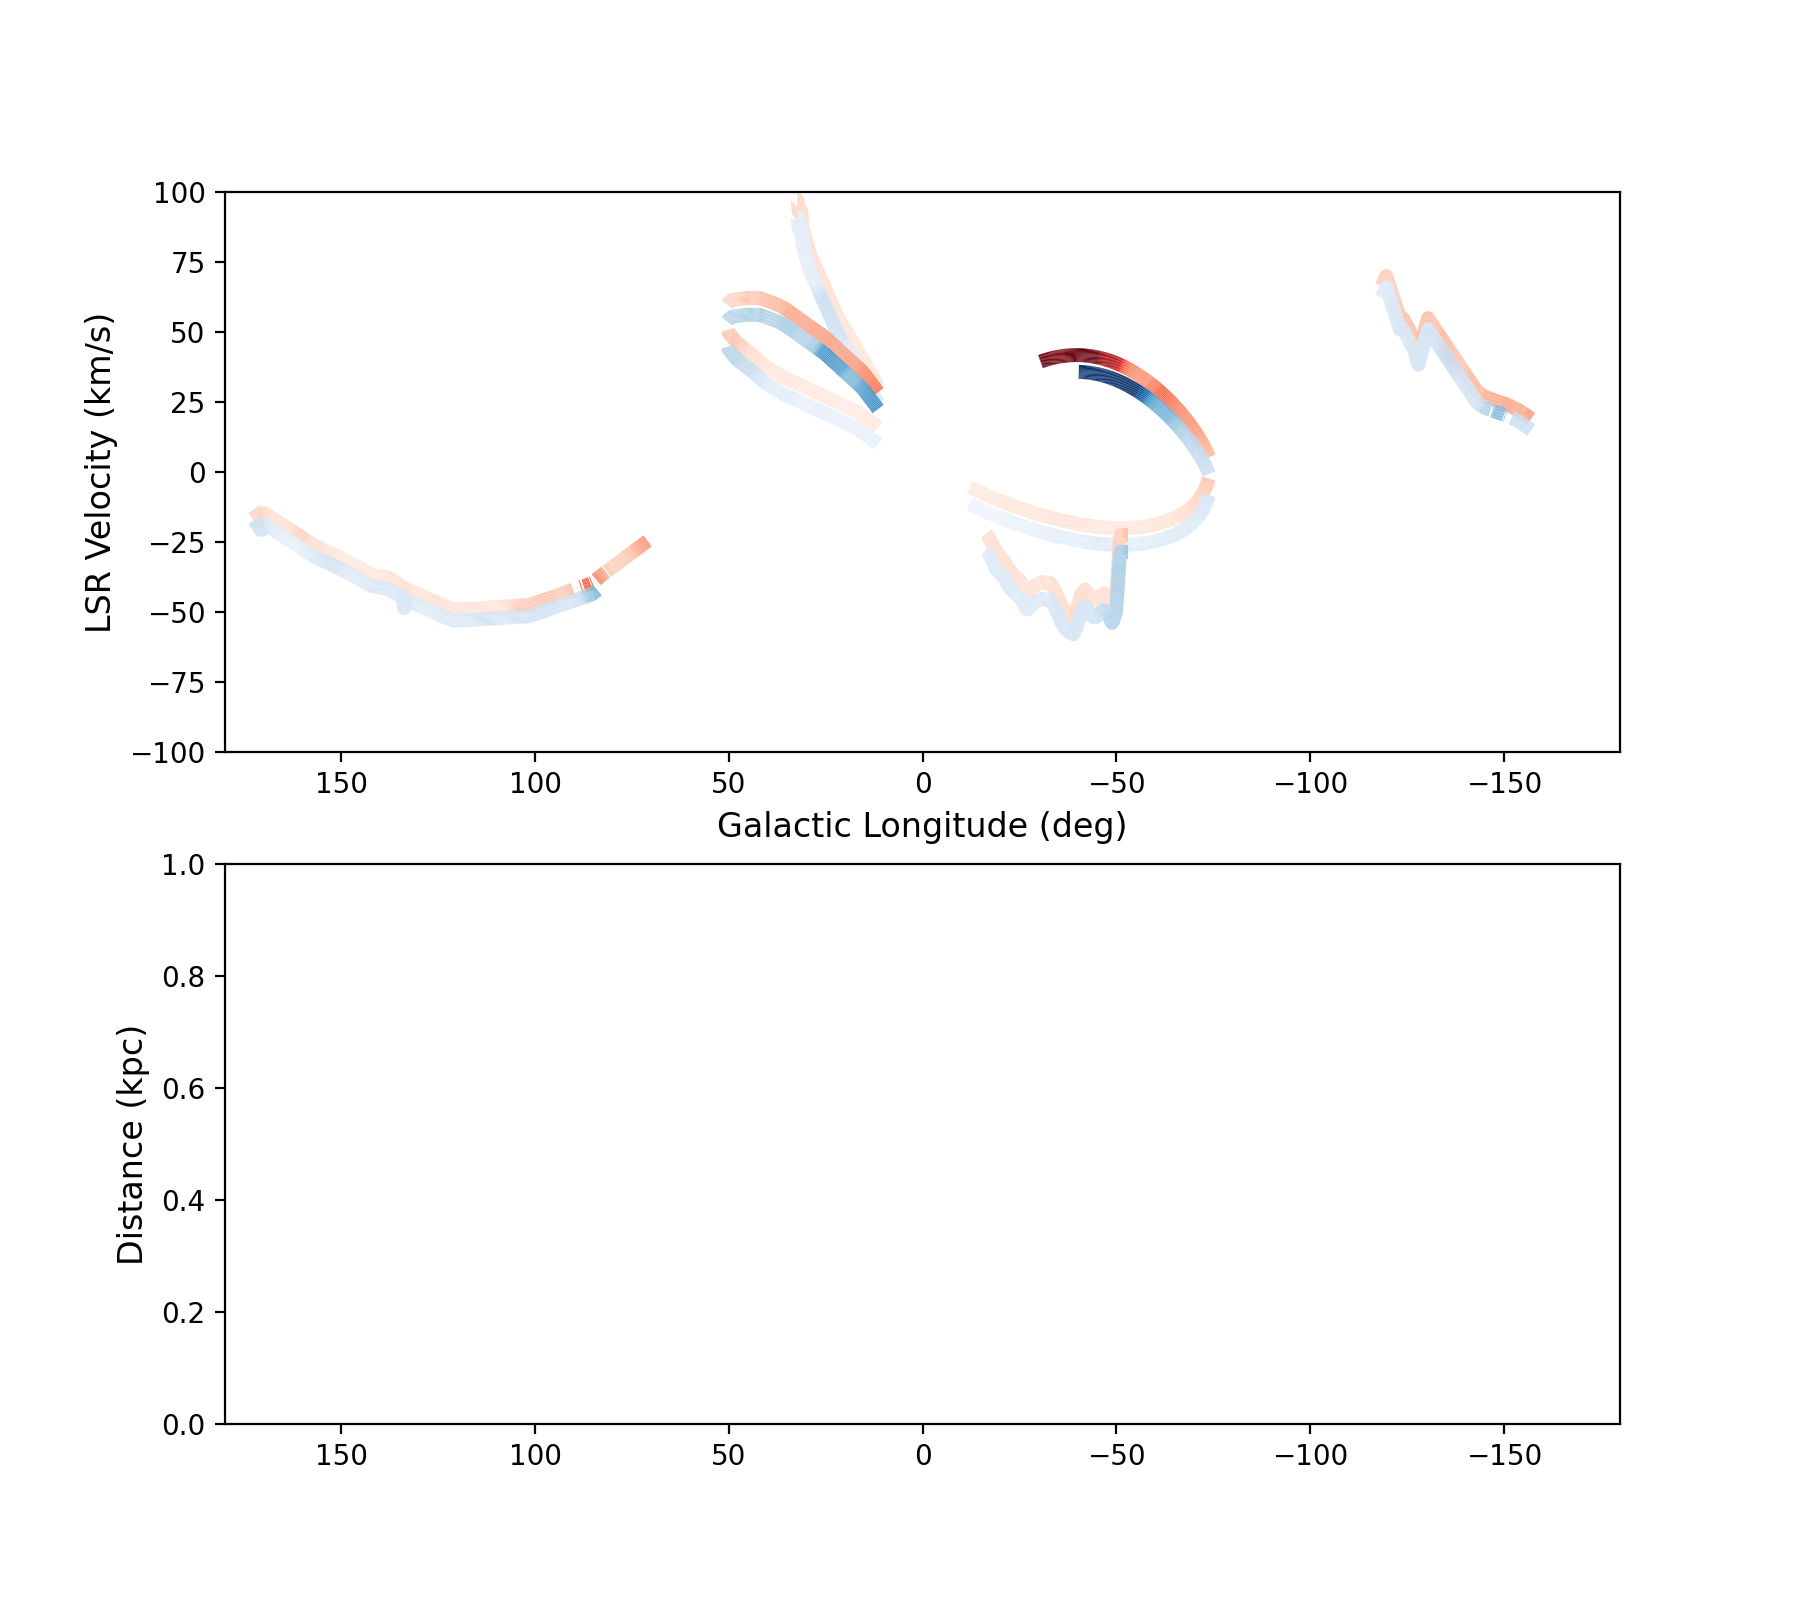

In [39]:
fig = plt.figure(figsize = (9,8))

ax = fig.add_subplot(211)
ax2 = fig.add_subplot(212, sharex = ax)

ax.set_xlabel("Galactic Longitude (deg)", fontsize = 12)
ax.set_ylabel("LSR Velocity (km/s)", fontsize = 12)
ax2.set_ylabel("Distance (kpc)", fontsize = 12)


line_pos = colored_line(Angle(crf_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    crf_vel_smooth_ha+3,
                    crf_Ha_H_pos[1,:],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(crf_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    crf_vel_smooth_ha-3,
                    crf_Ha_H_neg[1,:],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )


line_pos = colored_line(Angle(crn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    crn_vel_smooth_ha+3,
                    crn_Ha_H_pos[1,:],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(crn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    crn_vel_smooth_ha-3,
                    crn_Ha_H_neg[1,:],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )



line_pos = colored_line(Angle(ctn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    ctn_vel_smooth_ha+3,
                    ctn_Ha_H_pos[1,:],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(ctn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    ctn_vel_smooth_ha-3,
                    ctn_Ha_H_neg[1,:],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )

per_lon_mask = per_ha_fit_results["smoothed_longitude"] > 180.

line_pos = colored_line(Angle(per_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d")[per_lon_mask], 
                    per_vel_smooth_ha[per_lon_mask]+2,
                    per_Ha_H_pos[1,per_lon_mask],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(per_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d")[per_lon_mask], 
                    per_vel_smooth_ha[per_lon_mask]-2,
                    per_Ha_H_neg[1,per_lon_mask],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )



line_pos = colored_line(Angle(per_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d")[~per_lon_mask], 
                    per_vel_smooth_ha[~per_lon_mask]+2,
                    per_Ha_H_pos[1,~per_lon_mask],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(per_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d")[~per_lon_mask], 
                    per_vel_smooth_ha[~per_lon_mask]-2,
                    per_Ha_H_neg[1,~per_lon_mask],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_pos = colored_line(Angle(scn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    scn_vel_smooth_ha+3,
                    scn_Ha_H_pos[1,:],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(scn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    scn_vel_smooth_ha-3,
                    scn_Ha_H_neg[1,:],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )

line_pos = colored_line(Angle(sgf_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    sgf_vel_smooth_ha+3,
                    sgf_Ha_H_pos[1,:],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(sgf_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    sgf_vel_smooth_ha-3,
                    sgf_Ha_H_neg[1,:],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )


line_pos = colored_line(Angle(sgn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    sgn_vel_smooth_ha+3,
                    sgn_Ha_H_pos[1,:],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(sgn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    sgn_vel_smooth_ha-3,
                    sgn_Ha_H_neg[1,:],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )





# xlim = ax.get_xlim()
# Fake Points for legend
# ax.scatter([3000],[0], marker = "P", label = "Scutum", s = 100, color = "k", alpha = 0.5)
# ax.scatter([3000],[0], marker = "s", label = "Sagittarius", s = 100, color = "k", alpha = 0.5)
# ax.scatter([3000],[0], marker = "v", label = "Centaurus", s = 100, color = "k", alpha = 0.5)
# ax.scatter([3000],[0], marker = "o", label = "Carina", s = 100, color = "k", alpha = 0.5)
# ax.scatter([3000],[0], marker = "x", label = "Perseus", s = 100, color = "k", alpha = 0.5)

# lg = ax.legend(fontsize = 8, ncol = 5)
xlim = ax.set_xlim(-180,180)
ylim = ax.set_ylim(-100,100)


ax.invert_xaxis()

<IPython.core.display.Javascript object>


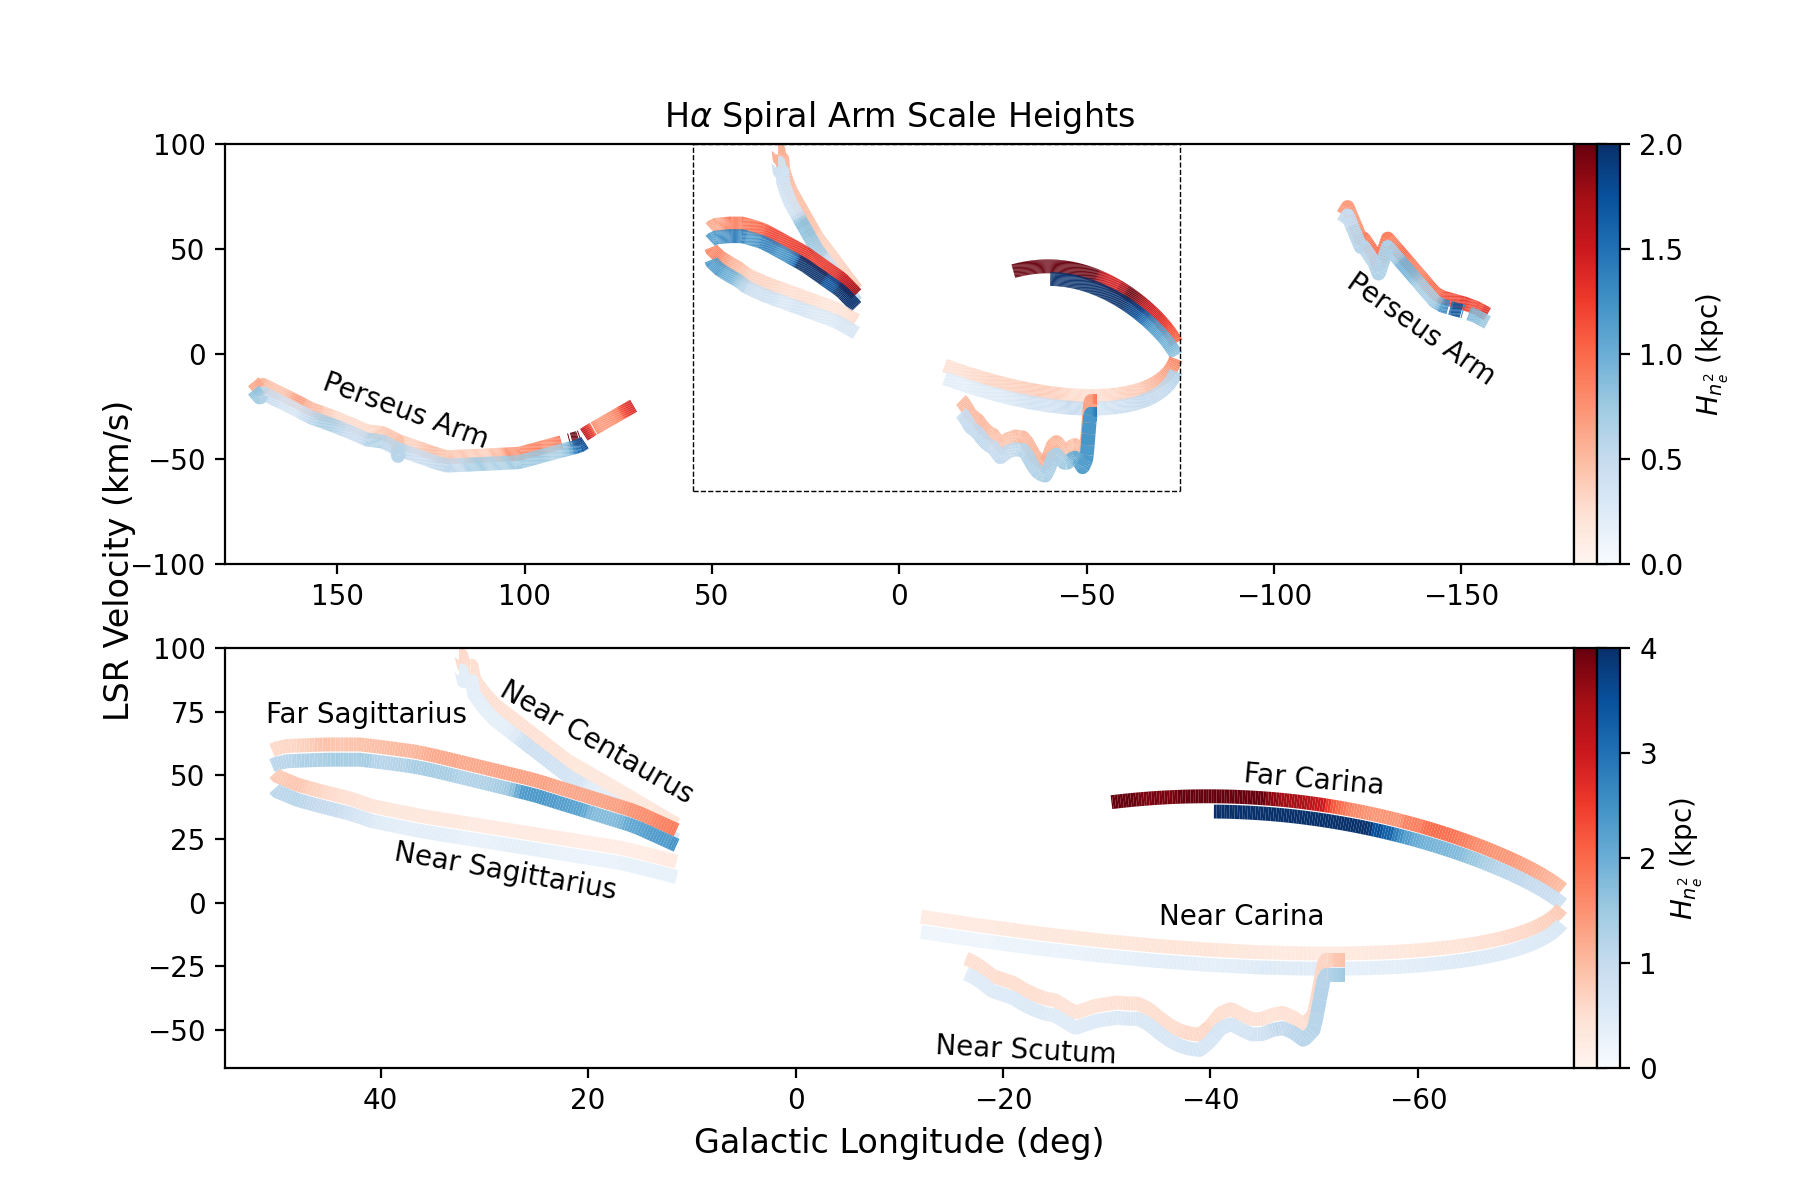

In [83]:
fig = plt.figure(constrained_layout=False, figsize = (9,6))
gs1 = fig.add_gridspec(nrows=2, ncols=60, wspace=0.0)
ax = fig.add_subplot(gs1[:-1, :-2])
cb_ax_pos = fig.add_subplot(gs1[:-1, -2])
cb_ax_neg = fig.add_subplot(gs1[:-1, -1])
ax2 = fig.add_subplot(gs1[-1,:-2])
cb_ax2_pos = fig.add_subplot(gs1[-1, -2])
cb_ax2_neg = fig.add_subplot(gs1[-1, -1])


ax2.set_xlabel("Galactic Longitude (deg)", fontsize = 12)
# ax.set_ylabel("LSR Velocity (km/s)", fontsize = 12)
ax2.set_ylabel("                                                        LSR Velocity (km/s)", fontsize = 12)


line_pos = colored_line(Angle(crf_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    crf_vel_smooth_ha+3,
                    crf_Ha_H_pos[1,:],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,2), 
                    lw = 5
                   )
line_neg = colored_line(Angle(crf_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    crf_vel_smooth_ha-3,
                    crf_Ha_H_neg[1,:],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,2), 
                    lw = 5
                   )


line_pos = colored_line(Angle(crn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    crn_vel_smooth_ha+3,
                    crn_Ha_H_pos[1,:],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,2), 
                    lw = 5
                   )
line_neg = colored_line(Angle(crn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    crn_vel_smooth_ha-3,
                    crn_Ha_H_neg[1,:],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,2), 
                    lw = 5
                   )



line_pos = colored_line(Angle(ctn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    ctn_vel_smooth_ha+3,
                    ctn_Ha_H_pos[1,:],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,2), 
                    lw = 5
                   )
line_neg = colored_line(Angle(ctn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    ctn_vel_smooth_ha-3,
                    ctn_Ha_H_neg[1,:],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,2), 
                    lw = 5
                   )

per_lon_mask = per_ha_fit_results["smoothed_longitude"] > 180.

line_pos = colored_line(Angle(per_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d")[per_lon_mask], 
                    per_vel_smooth_ha[per_lon_mask]+2,
                    per_Ha_H_pos[1,per_lon_mask],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,2), 
                    lw = 5
                   )
line_neg = colored_line(Angle(per_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d")[per_lon_mask], 
                    per_vel_smooth_ha[per_lon_mask]-2,
                    per_Ha_H_neg[1,per_lon_mask],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,2), 
                    lw = 5
                   )



line_pos = colored_line(Angle(per_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d")[~per_lon_mask], 
                    per_vel_smooth_ha[~per_lon_mask]+2,
                    per_Ha_H_pos[1,~per_lon_mask],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,2), 
                    lw = 5
                   )
line_neg = colored_line(Angle(per_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d")[~per_lon_mask], 
                    per_vel_smooth_ha[~per_lon_mask]-2,
                    per_Ha_H_neg[1,~per_lon_mask],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,2), 
                    lw = 5
                   )
line_pos = colored_line(Angle(scn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    scn_vel_smooth_ha+3,
                    scn_Ha_H_pos[1,:],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,2), 
                    lw = 5
                   )
line_neg = colored_line(Angle(scn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    scn_vel_smooth_ha-3,
                    scn_Ha_H_neg[1,:],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,2), 
                    lw = 5
                   )

line_pos = colored_line(Angle(sgf_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    sgf_vel_smooth_ha+3,
                    sgf_Ha_H_pos[1,:],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,2), 
                    lw = 5
                   )
line_neg = colored_line(Angle(sgf_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    sgf_vel_smooth_ha-3,
                    sgf_Ha_H_neg[1,:],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,2), 
                    lw = 5
                   )


line_pos = colored_line(Angle(sgn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    sgn_vel_smooth_ha+3,
                    sgn_Ha_H_pos[1,:],
                    ax,
                    cmap = "Reds",
                    norm = Normalize(0,2), 
                    lw = 5
                   )
line_neg = colored_line(Angle(sgn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    sgn_vel_smooth_ha-3,
                    sgn_Ha_H_neg[1,:],
                    ax,
                    cmap = "Blues",
                    norm = Normalize(0,2), 
                    lw = 5
                   )

xlim = ax.set_xlim(180,-180)
ylim = ax.set_ylim(-100,100)


cb1_pos = fig.colorbar(line_pos, cax = cb_ax_pos)
cb_ax_pos.axes.yaxis.set_ticklabels([])
cb1_neg = fig.colorbar(line_neg, cax=cb_ax_neg, label = "$H_{{n_{{e}}^2}}$ (kpc)")


# Zoomed in

line_pos = colored_line(Angle(crf_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    crf_vel_smooth_ha+3,
                    crf_Ha_H_pos[1,:],
                    ax2,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(crf_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    crf_vel_smooth_ha-3,
                    crf_Ha_H_neg[1,:],
                    ax2,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )


line_pos = colored_line(Angle(crn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    crn_vel_smooth_ha+3,
                    crn_Ha_H_pos[1,:],
                    ax2,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(crn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    crn_vel_smooth_ha-3,
                    crn_Ha_H_neg[1,:],
                    ax2,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )



line_pos = colored_line(Angle(ctn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    ctn_vel_smooth_ha+3,
                    ctn_Ha_H_pos[1,:],
                    ax2,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(ctn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    ctn_vel_smooth_ha-3,
                    ctn_Ha_H_neg[1,:],
                    ax2,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )

line_pos = colored_line(Angle(scn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    scn_vel_smooth_ha+3,
                    scn_Ha_H_pos[1,:],
                    ax2,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(scn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    scn_vel_smooth_ha-3,
                    scn_Ha_H_neg[1,:],
                    ax2,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )

line_pos = colored_line(Angle(sgf_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    sgf_vel_smooth_ha+3,
                    sgf_Ha_H_pos[1,:],
                    ax2,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(sgf_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    sgf_vel_smooth_ha-3,
                    sgf_Ha_H_neg[1,:],
                    ax2,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )


line_pos = colored_line(Angle(sgn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    sgn_vel_smooth_ha+3,
                    sgn_Ha_H_pos[1,:],
                    ax2,
                    cmap = "Reds",
                    norm = Normalize(0,4), 
                    lw = 5
                   )
line_neg = colored_line(Angle(sgn_ha_fit_results["smoothed_longitude"]*u.deg).wrap_at("180d"), 
                    sgn_vel_smooth_ha-3,
                    sgn_Ha_H_neg[1,:],
                    ax2,
                    cmap = "Blues",
                    norm = Normalize(0,4), 
                    lw = 5
                   )

xlim = ax2.set_xlim(55,-75)
ylim = ax2.set_ylim(-65,100)


cb2_pos = fig.colorbar(line_pos, cax = cb_ax2_pos)
cb_ax2_pos.axes.yaxis.set_ticklabels([])
cb2_neg = fig.colorbar(line_neg, cax=cb_ax2_neg, label = "$H_{{n_{{e}}^2}}$ (kpc)")



# Annotations

ax.plot(xlim, [ylim[0],ylim[0]], lw = 0.5, ls = "--", color = "k")
ax.plot(xlim, [ylim[1],ylim[1]], lw = 0.5, ls = "--", color = "k")
ax.plot([xlim[0],xlim[0]], ylim, lw = 0.5, ls = "--", color = "k")
ax.plot([xlim[1],xlim[1]], ylim, lw = 0.5, ls = "--", color = "k")


ax2.text(-50,40,"Far Carina", ha="center", va = "bottom", fontsize = 10, rotation = -5)
ax2.text(-35,-11,"Near Carina", ha="left", va = "bottom", fontsize = 10)

ax2.text(-31,-51,"Near Scutum", ha="right", va = "top", fontsize = 10, rotation = -3)

ax2.text(17,25,"Near Sagittarius", ha="right", va = "top", fontsize = 10, rotation = -10)
ax2.text(51,68,"Far Sagittarius", ha="left", va = "bottom", fontsize = 10)

ax2.text(29,89,"Near Centaurus", ha="left", va = "top", fontsize = 10, rotation = -30)


ax.text(155,-7,"Perseus Arm", ha="left", va = "top", fontsize = 10, rotation = -20)
ax.text(-118,41,"Perseus Arm", ha="left", va = "top", fontsize = 10, rotation = -35)


ax.set_title(r"H$\alpha$ Spiral Arm Scale Heights", fontsize = 12)


fig.savefig("Figures/v2025/LV_H-Alpha_ExtinctionCorrectedResults.png", 
            dpi = 300, 
            transparent = True)
fig.savefig("Figures/v2025/LV_H-Alpha_ExtinctionCorrectedResults.svg", 
#             dpi = 300, 
            transparent = True)

In [13]:
crn_rgal_interpolator = interp1d(crn_track[:,0], crn_track[:,3])
crn_rgal_smooth_ha = crn_rgal_interpolator(crn_ha_fit_results["smoothed_longitude"])
crn_rgal_smooth_hi = crn_rgal_interpolator(crn_hi_fit_results["smoothed_longitude"])

crf_rgal_interpolator = interp1d(crf_track[:,0], crf_track[:,3])
crf_rgal_smooth_ha = crf_rgal_interpolator(crf_ha_fit_results["smoothed_longitude"])
crf_rgal_smooth_hi = crf_rgal_interpolator(crf_hi_fit_results["smoothed_longitude"])

ctn_rgal_interpolator = interp1d(ctn_track[:,0], ctn_track[:,3])
ctn_rgal_smooth_ha = ctn_rgal_interpolator(ctn_ha_fit_results["smoothed_longitude"])
ctn_rgal_smooth_hi = ctn_rgal_interpolator(ctn_hi_fit_results["smoothed_longitude"])

per_rgal_interpolator = interp1d(per_track[:,0], per_track[:,3], fill_value=np.nan, bounds_error=False)
per_rgal_smooth_ha = per_rgal_interpolator(per_ha_fit_results["smoothed_longitude"])
per_rgal_smooth_hi = per_rgal_interpolator(per_hi_fit_results["smoothed_longitude"])

sgn_rgal_interpolator = interp1d(sgn_track[:,0], sgn_track[:,3])
sgn_rgal_smooth_ha = sgn_rgal_interpolator(sgn_ha_fit_results["smoothed_longitude"])
sgn_rgal_smooth_hi = sgn_rgal_interpolator(sgn_hi_fit_results["smoothed_longitude"])

sgf_rgal_interpolator = interp1d(sgf_track[:,0], sgf_track[:,3])
sgf_rgal_smooth_ha = sgf_rgal_interpolator(sgf_ha_fit_results["smoothed_longitude"])
sgf_rgal_smooth_hi = sgf_rgal_interpolator(sgf_hi_fit_results["smoothed_longitude"])

scn_rgal_interpolator = interp1d(scn_track[:,0], scn_track[:,3])
scn_rgal_smooth_ha = scn_rgal_interpolator(scn_ha_fit_results["smoothed_longitude"])
scn_rgal_smooth_hi = scn_rgal_interpolator(scn_hi_fit_results["smoothed_longitude"])

# H$\alpha$

<IPython.core.display.Javascript object>


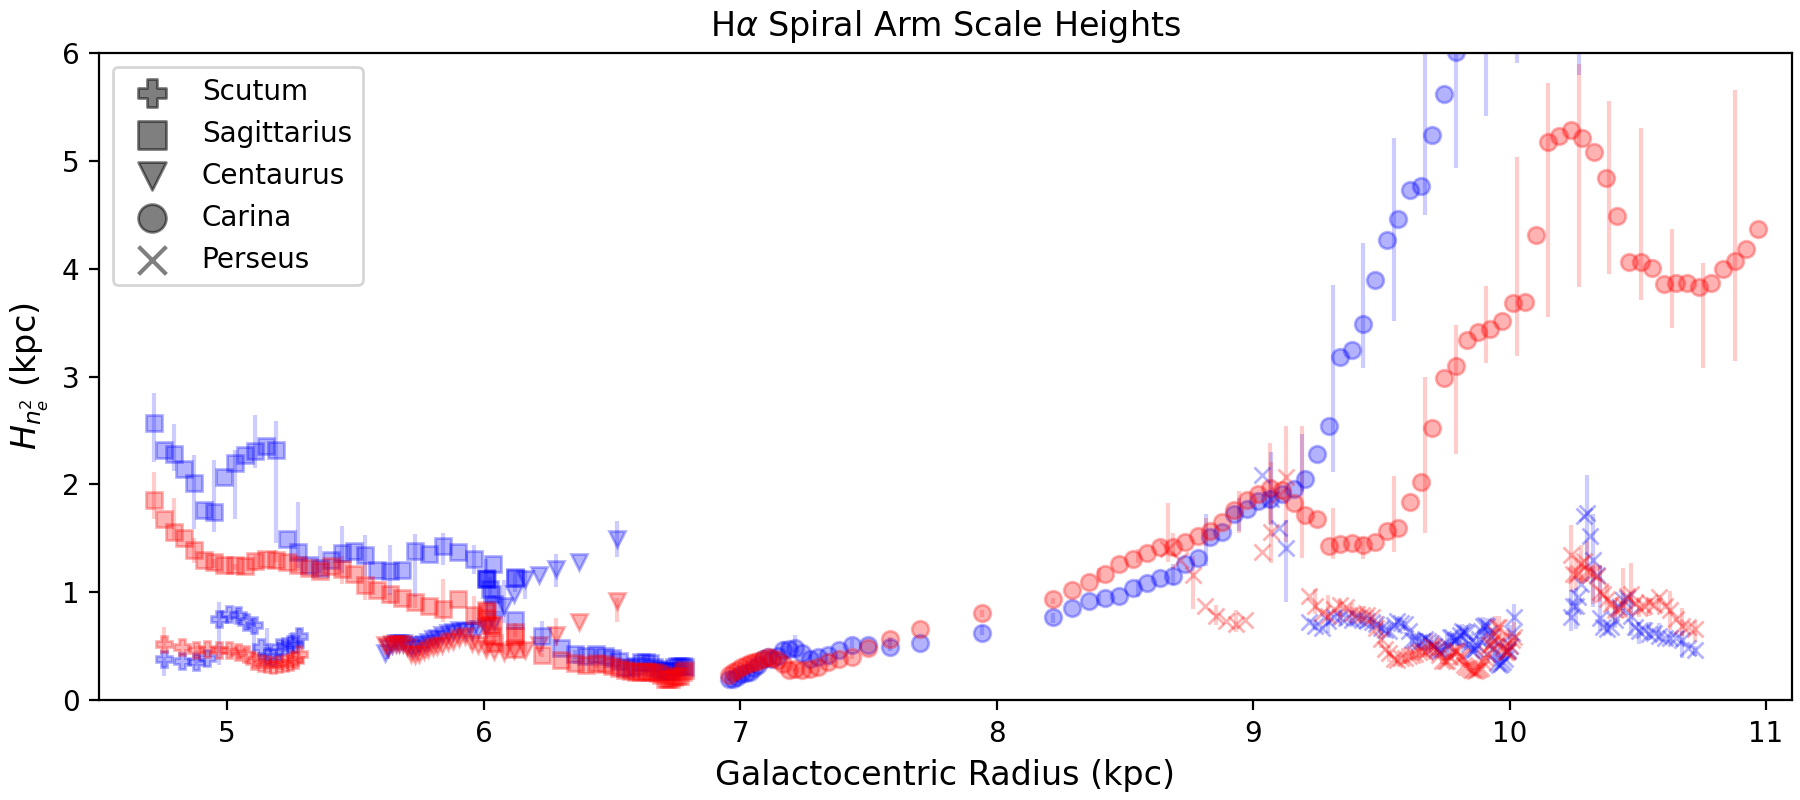

In [96]:
fig = plt.figure(figsize = (9,4), constrained_layout = True)

ax2 = fig.add_subplot(111)
# ax2 = ax.twinx()


# ax.set_ylabel("$H_{{N_{{HI}}}}$ (kpc)", fontsize = 12)
ax2.set_ylabel("$H_{{n_{{e}}^2}}$ (kpc)", fontsize = 12)
alpha = 0.3

# Carina Near
y = crn_Ha_H_neg[1,:]
yerr = [y - crn_Ha_H_neg[2,:], crn_Ha_H_neg[0,:] - y]

markers, caps, bars = ax2.errorbar(crn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 20, 
                                   markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crn_Ha_H_pos[1,:]
yerr = [y - crn_Ha_H_pos[0,:], crn_Ha_H_pos[2,:] - y]

markers, caps, bars = ax2.errorbar(crn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 20, 
                                   markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Carina Far
y = crf_Ha_H_neg[1,:]
yerr = [y - crf_Ha_H_neg[2,:], crf_Ha_H_neg[0,:] - y]

markers, caps, bars = ax2.errorbar(crf_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 8, 
                                   markevery = 3)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crf_Ha_H_pos[1,:]
yerr = [y - crf_Ha_H_pos[0,:], crf_Ha_H_pos[2,:] - y]

markers, caps, bars = ax2.errorbar(crf_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 8, 
                                   markevery = 3)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Centaurus Near
y = ctn_Ha_H_neg[1,:]
mask = ((ctn_Ha_H_pos[2,:] - ctn_Ha_H_pos[1,:]) > 5) | ((ctn_Ha_H_pos[1,:] - ctn_Ha_H_pos[0,:]) > 5)
y.mask = mask
yerr = [y - ctn_Ha_H_neg[2,:], ctn_Ha_H_neg[0,:] - y]

markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "v", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = ctn_Ha_H_pos[1,:]
yerr = [y - ctn_Ha_H_pos[0,:], ctn_Ha_H_pos[2,:] - y]

markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "v", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Sag Near
y = sgn_Ha_H_neg[1,:]
mask = ((sgn_Ha_H_pos[2,:] - sgn_Ha_H_pos[1,:]) > 5) | ((sgn_Ha_H_pos[1,:] - sgn_Ha_H_pos[0,:]) > 5)
y.mask = mask
yerr = [y - sgn_Ha_H_neg[2,:], sgn_Ha_H_neg[0,:] - y]

markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgn_Ha_H_pos[1,:]
mask = ((sgn_Ha_H_pos[2,:] - sgn_Ha_H_pos[1,:]) > 5) | ((sgn_Ha_H_pos[1,:] - sgn_Ha_H_pos[0,:]) > 5)
y.mask = mask
yerr = [y - sgn_Ha_H_pos[0,:], sgn_Ha_H_pos[2,:] - y]

markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Sag Far
y = sgf_Ha_H_neg[1,:]
mask = ((sgf_Ha_H_pos[2,:] - sgf_Ha_H_pos[1,:]) > 5) | ((sgf_Ha_H_pos[1,:] - sgf_Ha_H_pos[0,:]) > 5)
y.mask = mask
yerr = [y - sgf_Ha_H_neg[2,:], sgf_Ha_H_neg[0,:] - y]

markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgf_Ha_H_pos[1,:]
mask = ((sgf_Ha_H_pos[2,:] - sgf_Ha_H_pos[1,:]) > 5) | ((sgf_Ha_H_pos[1,:] - sgf_Ha_H_pos[0,:]) > 5)
y.mask = mask
yerr = [y - sgf_Ha_H_pos[0,:], sgf_Ha_H_pos[2,:] - y]

markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Scutum Near
y = scn_Ha_H_neg[1,:]
mask = ((scn_Ha_H_pos[2,:] - scn_Ha_H_pos[1,:]) > 5) | ((scn_Ha_H_pos[1,:] - scn_Ha_H_pos[0,:]) > 5)
y.mask = mask
yerr = [y - scn_Ha_H_neg[2,:], scn_Ha_H_neg[0,:] - y]

markers, caps, bars = ax2.errorbar(scn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "P", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = scn_Ha_H_pos[1,:]
mask = ((scn_Ha_H_pos[2,:] - scn_Ha_H_pos[1,:]) > 5) | ((scn_Ha_H_pos[1,:] - scn_Ha_H_pos[0,:]) > 5)
y.mask = mask
yerr = [y - scn_Ha_H_pos[0,:], scn_Ha_H_pos[2,:] - y]

markers, caps, bars = ax2.errorbar(scn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "P", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Perseus Near
vel_mask = ((per_ha_fit_results["smoothed_longitude"] < 203) & (per_ha_fit_results["smoothed_longitude"] > 173))
vel_mask |= ((per_ha_fit_results["smoothed_longitude"] < 65) & (per_ha_fit_results["smoothed_longitude"] > 42))
y = per_Ha_H_neg[1,:]
mask = ((per_Ha_H_pos[2,:] - per_Ha_H_pos[1,:]) > .75) | ((per_Ha_H_pos[1,:] - per_Ha_H_pos[0,:]) > .75)
mask |= y > 3
y.mask = mask | vel_mask
yerr = [y - per_Ha_H_neg[2,:], per_Ha_H_neg[0,:] - y]

markers, caps, bars = ax2.errorbar(per_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "x", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = per_Ha_H_pos[1,:]
mask = ((per_Ha_H_pos[2,:] - per_Ha_H_pos[1,:]) > .75) | ((per_Ha_H_pos[1,:] - per_Ha_H_pos[0,:]) > .75)
y.mask = mask | vel_mask
yerr = [y - per_Ha_H_pos[0,:], per_Ha_H_pos[2,:] - y]

markers, caps, bars = ax2.errorbar(per_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "x", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


xlim = ax2.get_xlim()
# Fake Points for legend
ax2.scatter([0],[0], marker = "P", label = "Scutum", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "s", label = "Sagittarius", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "v", label = "Centaurus", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "o", label = "Carina", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "x", label = "Perseus", s = 100, color = "k", alpha = 0.5)

lg = ax2.legend(fontsize = 10)

ax2.set_xlim(4.5,11.1)
ax2.set_ylim(0, 6)



ax2.set_xlabel("Galactocentric Radius (kpc)", fontsize = 12)
ax2.set_title(r"H$\alpha$ Spiral Arm Scale Heights", fontsize = 12)

fig.savefig("Figures/v2025/ScaleHeight+MidplaneIntensity_Plots/RGal_H-Alpha_ExtinctionCorrectedResults.png", 
            dpi = 300, 
            transparent = True)
fig.savefig("Figures/v2025/ScaleHeight+MidplaneIntensity_Plots/RGal_H-Alpha_ExtinctionCorrectedResults.svg", 
#             dpi = 300, 
            transparent = True)

In [118]:
crn_ha_fit_results.keys()

dict_keys(['median_longitude', 'slopes_pos', 'slopes_neg', 'intercept_pos', 'intercept_neg', 'slopes_pos_err', 'slopes_neg_err', 'intercept_pos_err', 'intercept_neg_err', 'median_distance', 'slopes_pos_dr', 'slopes_neg_dr', 'intercept_pos_dr', 'intercept_neg_dr', 'slopes_pos_dr_err', 'slopes_neg_dr_err', 'intercept_pos_dr_err', 'intercept_neg_dr_err', 'smoothed_longitude', 'smoothed_distance', 'smoothed_slopes_pos', 'smoothed_slopes_neg', 'smoothed_intercepts_pos', 'smoothed_intercepts_neg', 'smoothed_slopes_pos_dr', 'smoothed_slopes_neg_dr', 'smoothed_intercepts_pos_dr', 'smoothed_intercepts_neg_dr'])

<IPython.core.display.Javascript object>


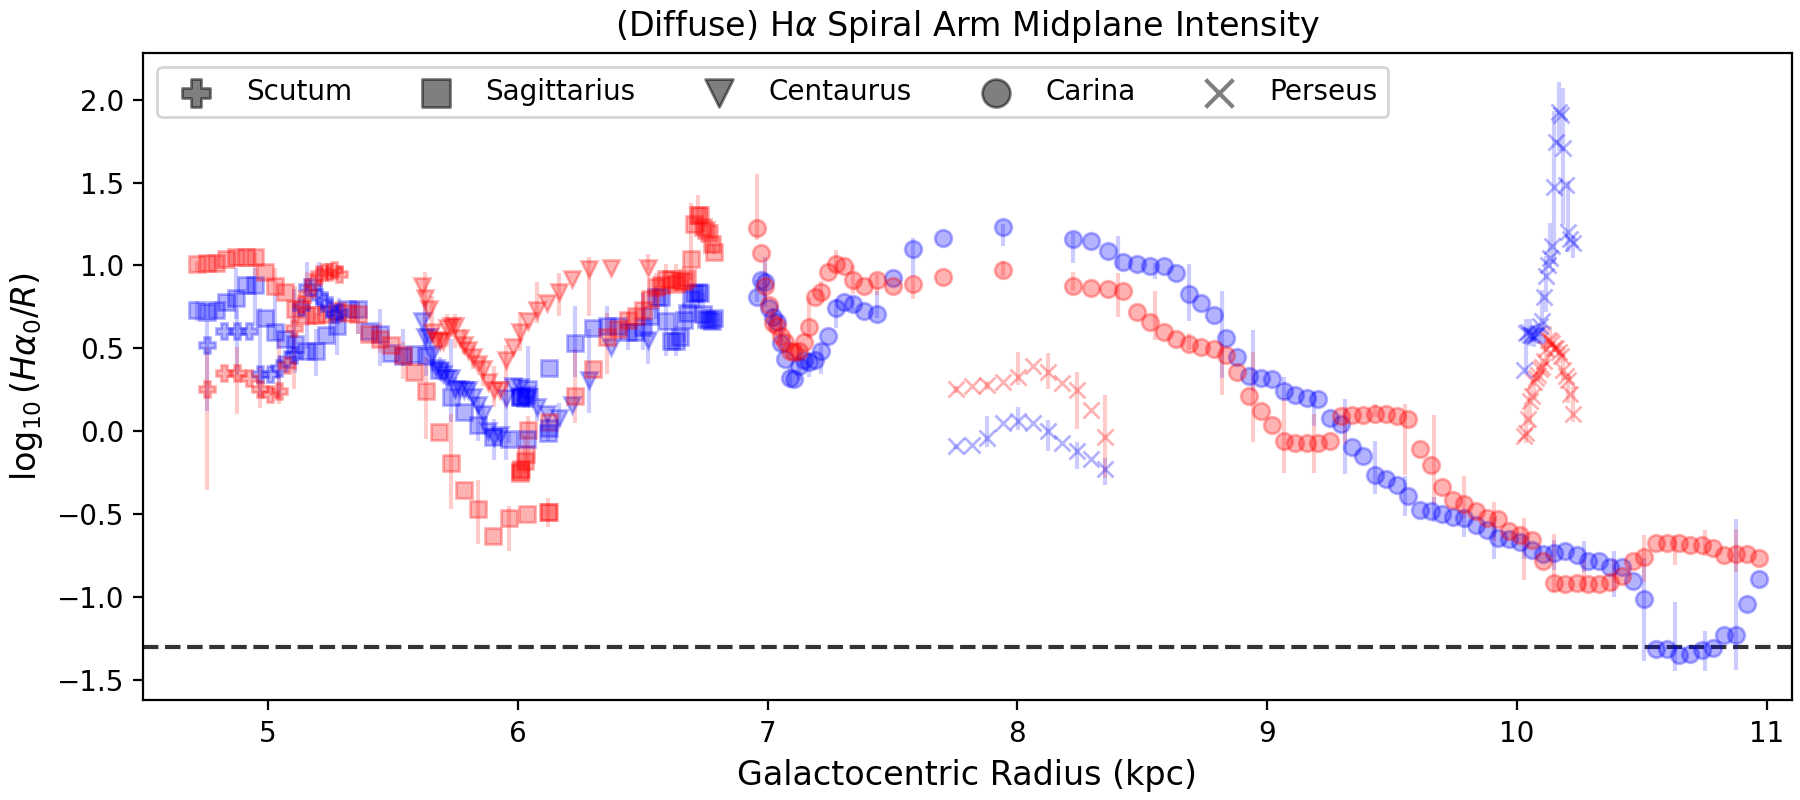

In [113]:
fig = plt.figure(figsize = (9,4), constrained_layout = True)

ax2 = fig.add_subplot(111)
# ax2 = ax.twinx()


# ax.set_ylabel("$H_{{N_{{HI}}}}$ (kpc)", fontsize = 12)
ax2.set_ylabel(r"$\log_{{10}}(H\alpha_{{0}} / R)$", fontsize = 12)
alpha = 0.3

# Carina Near
y = crn_ha_fit_results["smoothed_intercepts_neg_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(crn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 20, 
                                   markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crn_ha_fit_results["smoothed_intercepts_pos_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(crn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 20, 
                                   markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# # Carina Far
y = crf_ha_fit_results["smoothed_intercepts_neg_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(crf_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 8, 
                                   markevery = 3)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crf_ha_fit_results["smoothed_intercepts_pos_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(crf_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 8, 
                                   markevery = 3)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# # Centaurus Near
y = ctn_ha_fit_results["smoothed_intercepts_neg_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "v", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = ctn_ha_fit_results["smoothed_intercepts_pos_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "v", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# # Sag Near
y = sgn_ha_fit_results["smoothed_intercepts_neg_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgn_ha_fit_results["smoothed_intercepts_pos_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# # Sag Far
y = sgf_ha_fit_results["smoothed_intercepts_neg_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgf_ha_fit_results["smoothed_intercepts_pos_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# # Scutum Near
y = scn_ha_fit_results["smoothed_intercepts_neg_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]


markers, caps, bars = ax2.errorbar(scn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "P", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = scn_ha_fit_results["smoothed_intercepts_pos_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(scn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "P", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# # Perseus Near
vel_mask = ((per_ha_fit_results["smoothed_longitude"] < 203) & (per_ha_fit_results["smoothed_longitude"] > 173))
vel_mask |= ((per_ha_fit_results["smoothed_longitude"] < 65) & (per_ha_fit_results["smoothed_longitude"] > 42))
y = per_ha_fit_results["smoothed_intercepts_neg_dr"][:,vel_mask] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(per_rgal_smooth_ha[vel_mask], 
                                   y, 
                                   yerr = yerr,
                                   fmt = "x", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = per_ha_fit_results["smoothed_intercepts_pos_dr"][:,vel_mask] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(per_rgal_smooth_ha[vel_mask], 
                                   y, 
                                   yerr = yerr,
                                   fmt = "x", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


xlim = ax2.get_xlim()
# Fake Points for legend
ax2.scatter([0],[0], marker = "P", label = "Scutum", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "s", label = "Sagittarius", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "v", label = "Centaurus", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "o", label = "Carina", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "x", label = "Perseus", s = 100, color = "k", alpha = 0.5)

lg = ax2.legend(fontsize = 10, ncol = 5)

ax2.set_xlim(4.5,11.1)
# ax2.set_ylim(-4, 4.5)
ax2.axhline(np.log10(.05), ls = "--", color = "k", alpha = 0.8, zorder = 0)


ax2.set_xlabel("Galactocentric Radius (kpc)", fontsize = 12)
ax2.set_title(r"(Diffuse) H$\alpha$ Spiral Arm Midplane Intensity", fontsize = 12)

fig.savefig("Figures/v2025/ScaleHeight+MidplaneIntensity_Plots/RGal_H-Alpha_Midplane_ExtinctionCorrectedResults.png", 
            dpi = 300, 
            transparent = True)
fig.savefig("Figures/v2025/ScaleHeight+MidplaneIntensity_Plots/RGal_H-Alpha_Midplane_ExtinctionCorrectedResults.svg", 
#             dpi = 300, 
            transparent = True)

In [78]:
fig = plt.figure(figsize = (9,4), constrained_layout = True)

ax2 = fig.add_subplot(111)
# ax2 = ax.twinx()


# ax.set_ylabel("$H_{{N_{{HI}}}}$ (kpc)", fontsize = 12)
ax2.set_ylabel(r"$\log_{{10}}(H\alpha_{{0}} / R)$", fontsize = 12)
alpha = 0.3

# Carina Near
y = crn_ha_fit_results["smoothed_intercepts_neg_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(crn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 20, 
                                   markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crn_ha_fit_results["smoothed_intercepts_pos_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(crn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 20, 
                                   markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# # Carina Far
y = crf_ha_fit_results["smoothed_intercepts_neg_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(crf_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 8, 
                                   markevery = 3)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crf_ha_fit_results["smoothed_intercepts_pos_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(crf_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 8, 
                                   markevery = 3)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# # Centaurus Near
y = ctn_ha_fit_results["smoothed_intercepts_neg_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "v", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = ctn_ha_fit_results["smoothed_intercepts_pos_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "v", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# # Sag Near
y = sgn_ha_fit_results["smoothed_intercepts_neg_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgn_ha_fit_results["smoothed_intercepts_pos_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# # Sag Far
y = sgf_ha_fit_results["smoothed_intercepts_neg_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgf_ha_fit_results["smoothed_intercepts_pos_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# # Scutum Near
y = scn_ha_fit_results["smoothed_intercepts_neg_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]


markers, caps, bars = ax2.errorbar(scn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "P", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = scn_ha_fit_results["smoothed_intercepts_pos_dr"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(scn_rgal_smooth_ha, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "P", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# # Perseus Near
vel_mask = ((per_ha_fit_results["smoothed_longitude"] < 203) & (per_ha_fit_results["smoothed_longitude"] > 173))
vel_mask |= ((per_ha_fit_results["smoothed_longitude"] < 65) & (per_ha_fit_results["smoothed_longitude"] > 42))
y = per_ha_fit_results["smoothed_intercepts_neg_dr"][:,vel_mask] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(per_rgal_smooth_ha[vel_mask], 
                                   y, 
                                   yerr = yerr,
                                   fmt = "x", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = per_ha_fit_results["smoothed_intercepts_pos_dr"][:,vel_mask] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(per_rgal_smooth_ha[vel_mask], 
                                   y, 
                                   yerr = yerr,
                                   fmt = "x", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


xlim = ax2.get_xlim()
# Fake Points for legend
ax2.scatter([0],[0], marker = "P", label = "Scutum", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "s", label = "Sagittarius", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "v", label = "Centaurus", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "o", label = "Carina", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "x", label = "Perseus", s = 100, color = "k", alpha = 0.5)

lg = ax2.legend(fontsize = 10, ncol = 5)

ax2.set_xlim(4.5,11.1)
# ax2.set_ylim(-4, 4.5)
ax2.axhline(np.log10(.05), ls = "--", color = "k", alpha = 0.8, zorder = 0)


ax2.set_xlabel("Galactocentric Radius (kpc)", fontsize = 12)
ax2.set_title(r"(Diffuse) H$\alpha$ Spiral Arm Midplane Intensity", fontsize = 12)

fig.savefig("Figures/v2025/ScaleHeight+MidplaneIntensity_Plots/RGal_H-Alpha_Midplane_ExtinctionCorrectedResults.png", 
            dpi = 300, 
            transparent = True)
fig.savefig("Figures/v2025/ScaleHeight+MidplaneIntensity_Plots/RGal_H-Alpha_Midplane_ExtinctionCorrectedResults.svg", 
#             dpi = 300, 
            transparent = True)

(248,)

In [79]:
y[1,:].shape

(248,)

# HI

<IPython.core.display.Javascript object>


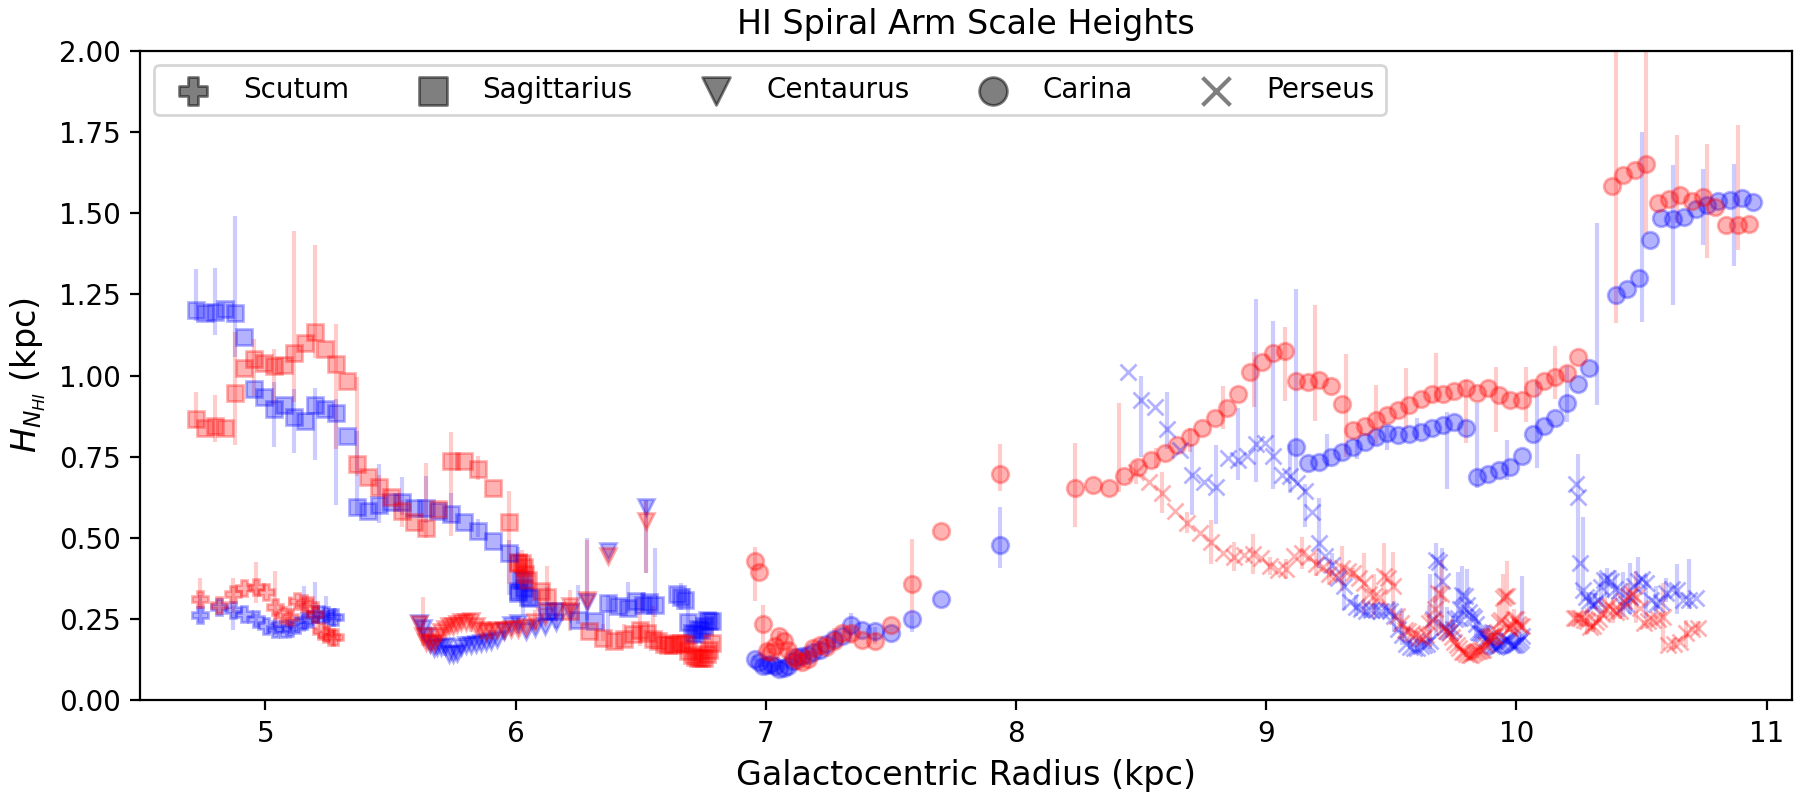

In [116]:
fig = plt.figure(figsize = (9,4), constrained_layout = True)

ax2 = fig.add_subplot(111)
# ax2 = ax.twinx()


ax.set_ylabel("$H_{{N_{{HI}}}}$ (kpc)", fontsize = 12)
# ax2.set_ylabel("$H_{{n_{{e}}^2}}$ (kpc)", fontsize = 12)
alpha = 0.3

# Carina Near
y = crn_HI_H_neg[1,:]
yerr = [y - crn_HI_H_neg[2,:], crn_HI_H_neg[0,:] - y]

markers, caps, bars = ax2.errorbar(crn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 20, 
                                   markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crn_HI_H_pos[1,:]
yerr = [y - crn_HI_H_pos[0,:], crn_HI_H_pos[2,:] - y]

markers, caps, bars = ax2.errorbar(crn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 20, 
                                   markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Carina Far
y = crf_HI_H_neg[1,:]
yerr = [y - crf_HI_H_neg[2,:], crf_HI_H_neg[0,:] - y]

markers, caps, bars = ax2.errorbar(crf_rgal_smooth_hi[~y.mask], 
                                   y[~y.mask], 
                                   yerr = [yerr[0][~y.mask],yerr[1][~y.mask]],
                                   fmt = "o", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 8, 
                                   markevery = 3)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crf_HI_H_pos[1,:]
yerr = [y - crf_HI_H_pos[0,:], crf_HI_H_pos[2,:] - y]

markers, caps, bars = ax2.errorbar(crf_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 8, 
                                   markevery = 3)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Centaurus Near
y = ctn_HI_H_neg[1,:]
mask = ((ctn_HI_H_pos[2,:] - ctn_HI_H_pos[1,:]) > .5) | ((ctn_HI_H_pos[1,:] - ctn_HI_H_pos[0,:]) > .5)
y.mask = mask
yerr = [y - ctn_HI_H_neg[2,:], ctn_HI_H_neg[0,:] - y]

markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "v", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = ctn_HI_H_pos[1,:]
yerr = [y - ctn_HI_H_pos[0,:], ctn_HI_H_pos[2,:] - y]

markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "v", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Sag Near
y = sgn_HI_H_neg[1,:]
mask = ((sgn_HI_H_pos[2,:] - sgn_HI_H_pos[1,:]) > .5) | ((sgn_HI_H_pos[1,:] - sgn_HI_H_pos[0,:]) > .5)

yerr = [y - sgn_HI_H_neg[2,:], sgn_HI_H_neg[0,:] - y]
mask |= yerr[0].data <0
mask |= yerr[1].data <0
y.mask = mask
markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_hi[~y.mask], 
                                   y[~y.mask], 
                                   yerr = [yerr[0][~y.mask],yerr[1][~y.mask]],
                                   fmt = "s", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgn_HI_H_pos[1,:]
mask = ((sgn_HI_H_pos[2,:] - sgn_HI_H_pos[1,:]) > .5) | ((sgn_HI_H_pos[1,:] - sgn_HI_H_pos[0,:]) > .5)
y.mask = mask
yerr = [y - sgn_HI_H_pos[0,:], sgn_HI_H_pos[2,:] - y]

markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Sag Far
y = sgf_HI_H_neg[1,:]
mask = ((sgf_HI_H_pos[2,:] - sgf_HI_H_pos[1,:]) > .5) | ((sgf_HI_H_pos[1,:] - sgf_HI_H_pos[0,:]) > .5)
y.mask = mask
yerr = [y - sgf_HI_H_neg[2,:], sgf_HI_H_neg[0,:] - y]

markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgf_HI_H_pos[1,:]
mask = ((sgf_HI_H_pos[2,:] - sgf_HI_H_pos[1,:]) > .5) | ((sgf_HI_H_pos[1,:] - sgf_HI_H_pos[0,:]) > .5)
y.mask = mask
yerr = [y - sgf_HI_H_pos[0,:], sgf_HI_H_pos[2,:] - y]

markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Scutum Near
y = scn_HI_H_neg[1,:]
mask = ((scn_HI_H_pos[2,:] - scn_HI_H_pos[1,:]) > .5) | ((scn_HI_H_pos[1,:] - scn_HI_H_pos[0,:]) > .5)
y.mask = mask
yerr = [y - scn_HI_H_neg[2,:], scn_HI_H_neg[0,:] - y]

markers, caps, bars = ax2.errorbar(scn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "P", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = scn_HI_H_pos[1,:]
mask = ((scn_HI_H_pos[2,:] - scn_HI_H_pos[1,:]) > .5) | ((scn_HI_H_pos[1,:] - scn_HI_H_pos[0,:]) > .5)
y.mask = mask
yerr = [y - scn_HI_H_pos[0,:], scn_HI_H_pos[2,:] - y]

markers, caps, bars = ax2.errorbar(scn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "P", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Perseus Near
vel_mask = ((per_hi_fit_results["smoothed_longitude"] < 203) & (per_hi_fit_results["smoothed_longitude"] > 173))
vel_mask |= ((per_hi_fit_results["smoothed_longitude"] < 65) & (per_hi_fit_results["smoothed_longitude"] > 42))
y = per_HI_H_neg[1,:]
mask = ((per_HI_H_pos[2,:] - per_HI_H_pos[1,:]) > .5) | ((per_HI_H_pos[1,:] - per_HI_H_pos[0,:]) > .5)
y.mask = mask | vel_mask
yerr = [y - per_HI_H_neg[2,:], per_HI_H_neg[0,:] - y]

markers, caps, bars = ax2.errorbar(per_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "x", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = per_HI_H_pos[1,:]
mask = ((per_HI_H_pos[2,:] - per_HI_H_pos[1,:]) > .5) | ((per_HI_H_pos[1,:] - per_HI_H_pos[0,:]) > .5)

yerr = [y - per_HI_H_pos[0,:], per_HI_H_pos[2,:] - y]
mask |= yerr[0] <0
mask |= yerr[1] <0
y.mask = mask | vel_mask
markers, caps, bars = ax2.errorbar(per_rgal_smooth_hi[~y.mask], 
                                   y[~y.mask], 
                                   yerr = [yerr[0][~y.mask],yerr[0][~y.mask]],
                                   fmt = "x", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


xlim = ax2.get_xlim()
# Fake Points for legend
ax2.scatter([0],[0], marker = "P", label = "Scutum", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "s", label = "Sagittarius", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "v", label = "Centaurus", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "o", label = "Carina", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "x", label = "Perseus", s = 100, color = "k", alpha = 0.5)

lg = ax2.legend(fontsize = 10, ncol = 5, loc = "upper left")

ax2.set_xlim(4.5,11.1)
ax2.set_ylim(0, 2)



ax2.set_xlabel("Galactocentric Radius (kpc)", fontsize = 12)
ax2.set_title(r"HI Spiral Arm Scale Heights", fontsize = 12)
ax2.set_ylabel("$H_{{N_{{HI}}}}$ (kpc)", fontsize = 12)

fig.savefig("Figures/v2025/ScaleHeight+MidplaneIntensity_Plots/RGal_HI_Results.png", 
            dpi = 300, 
            transparent = True)
fig.savefig("Figures/v2025/ScaleHeight+MidplaneIntensity_Plots/RGal_HI_Results.svg", 
#             dpi = 300, 
            transparent = True)


<IPython.core.display.Javascript object>


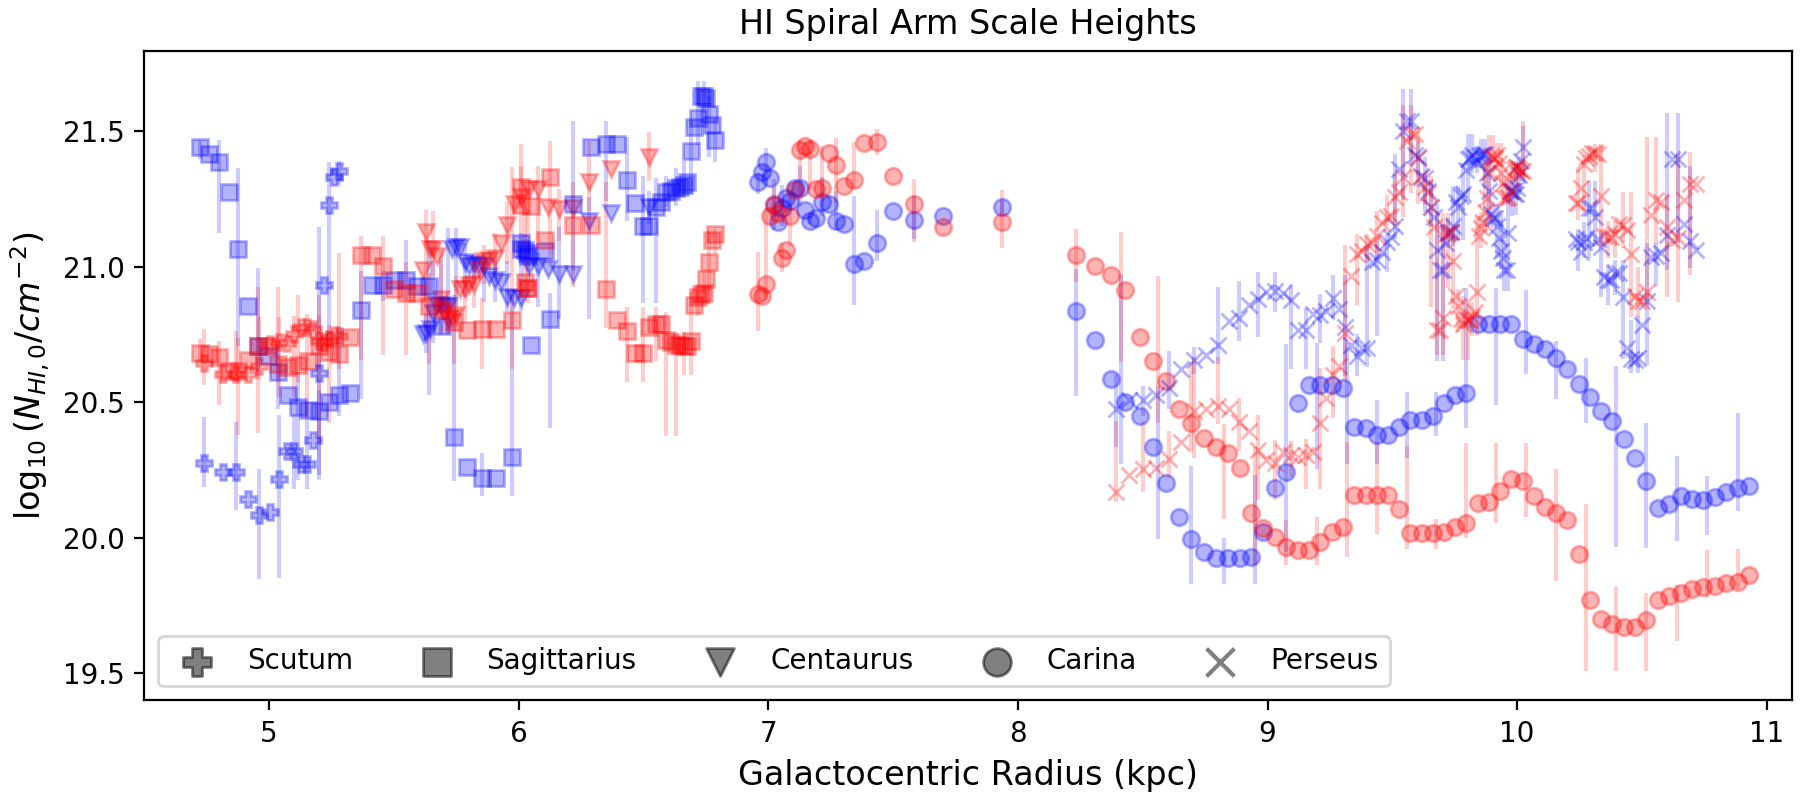

Text(0, 0.5, '$\\log_{{10}}(N_{{HI,0}}/cm^{{-2}})$')

In [111]:
fig = plt.figure(figsize = (9,4), constrained_layout = True)

ax2 = fig.add_subplot(111)
# ax2 = ax.twinx()


ax.set_ylabel("$H_{{N_{{HI}}}}$ (kpc)", fontsize = 12)
# ax2.set_ylabel("$H_{{n_{{e}}^2}}$ (kpc)", fontsize = 12)
alpha = 0.3

# Carina Near
y = crn_hi_fit_results["smoothed_intercepts_neg"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(crn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 20, 
                                   markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crn_hi_fit_results["smoothed_intercepts_pos"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(crn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 20, 
                                   markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Carina Far
y = crf_hi_fit_results["smoothed_intercepts_neg"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(crf_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 8, 
                                   markevery = 3)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crf_hi_fit_results["smoothed_intercepts_pos"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(crf_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "o", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 8, 
                                   markevery = 3)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Centaurus Near
y = ctn_hi_fit_results["smoothed_intercepts_neg"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "v", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = ctn_hi_fit_results["smoothed_intercepts_pos"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "v", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Sag Near
y = sgn_hi_fit_results["smoothed_intercepts_pos"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]
markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgn_hi_fit_results["smoothed_intercepts_neg"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Sag Far
y = sgf_hi_fit_results["smoothed_intercepts_pos"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgf_hi_fit_results["smoothed_intercepts_neg"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "s", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Scutum Near
y = scn_hi_fit_results["smoothed_intercepts_pos"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(scn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "P", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = scn_hi_fit_results["smoothed_intercepts_neg"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = y[1,:]

markers, caps, bars = ax2.errorbar(scn_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "P", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Perseus Near
vel_mask = ((per_hi_fit_results["smoothed_longitude"] < 203) & (per_hi_fit_results["smoothed_longitude"] > 173))
vel_mask |= ((per_hi_fit_results["smoothed_longitude"] < 65) & (per_hi_fit_results["smoothed_longitude"] > 42))
y = per_hi_fit_results["smoothed_intercepts_pos"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = np.ma.masked_array(y[1,:], mask = vel_mask)


markers, caps, bars = ax2.errorbar(per_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "x", 
                                   color = "b", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = per_hi_fit_results["smoothed_intercepts_neg"] / np.log(10)
yerr = [y[1,:] - y[0,:], y[2,:] - y[1,:]]
y = np.ma.masked_array(y[1,:], mask = vel_mask)

markers, caps, bars = ax2.errorbar(per_rgal_smooth_hi, 
                                   y, 
                                   yerr = yerr,
                                   fmt = "x", 
                                   color = "r", 
                                   alpha = alpha, 
                                   errorevery = 10, 
                                   markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


xlim = ax2.get_xlim()
ylim = ax2.get_ylim()
# Fake Points for legend
ax2.scatter([0],[0], marker = "P", label = "Scutum", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "s", label = "Sagittarius", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "v", label = "Centaurus", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "o", label = "Carina", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "x", label = "Perseus", s = 100, color = "k", alpha = 0.5)

lg = ax2.legend(fontsize = 10, ncol = 5)

ax2.set_xlim(4.5,11.1)
ax2.set_ylim(ylim)



ax2.set_xlabel("Galactocentric Radius (kpc)", fontsize = 12)
ax2.set_title(r"HI Spiral Arm Scale Heights", fontsize = 12)
ax2.set_ylabel("$\log_{{10}}(N_{{HI,0}}/cm^{{-2}})$", fontsize = 12)

# fig.savefig("Figures/v2025/ScaleHeight+MidplaneIntensity_Plots/RGal_HI_Midplane_Results.png", 
#             dpi = 300, 
#             transparent = True)
# fig.savefig("Figures/v2025/ScaleHeight+MidplaneIntensity_Plots/RGal_HI_Midplane_Results.svg", 
# #             dpi = 300, 
#             transparent = True)
